In [2]:
# ============================================================
# BERTopic + WordCloud — Montagu Letters (EN + FR)
# Run LOCALLY on your own computer, using precomputed LaBSE embeddings
# ============================================================

# use montagu-bertopic environment

import numpy as np
import pandas as pd
import os

from bertopic import BERTopic
from umap import UMAP
from hdbscan import HDBSCAN
from sklearn.feature_extraction.text import CountVectorizer


A module that was compiled using NumPy 1.x cannot be run in
NumPy 2.3.5 as it may crash. To support both 1.x and 2.x
versions of NumPy, modules must be compiled with NumPy 2.0.
Some module may need to rebuild instead e.g. with 'pybind11>=2.12'.

If you are a user of the module, the easiest solution will be to
downgrade to 'numpy<2' or try to upgrade the affected module.
We expect that some modules will need time to support NumPy 2.

Traceback (most recent call last):  File "<frozen runpy>", line 198, in _run_module_as_main
  File "<frozen runpy>", line 88, in _run_code
  File "/Users/mervetekgurler/anaconda3/envs/montagu_bertopic/lib/python3.12/site-packages/ipykernel_launcher.py", line 18, in <module>
    app.launch_new_instance()
  File "/Users/mervetekgurler/anaconda3/envs/montagu_bertopic/lib/python3.12/site-packages/traitlets/config/application.py", line 1082, in launch_instance
    app.start()
  File "/Users/mervetekgurler/anaconda3/envs/montagu_bertopic/lib/python3.12/site-pack

In [4]:
# ============================================================
# Step 1: Load your precomputed embeddings + metadata
# ============================================================
embeddings_path = "../../output/montagu_labse_embeddings.npy"
metadata_path = "../../output/montagu_labse_metadata.csv"

embeddings = np.load(embeddings_path)
df_all = pd.read_csv(metadata_path)

print("Embeddings shape:", embeddings.shape)
print("Metadata shape:", df_all.shape)
assert embeddings.shape[0] == len(df_all), "Embeddings and metadata row counts don't match!"

# The text BERTopic will model topics over — one sentence per row
docs = df_all["sentence"].tolist()


Embeddings shape: (5460, 768)
Metadata shape: (5460, 4)


In [7]:
import pandas as pd

df_all = pd.read_csv("../../output/montagu_labse_metadata.csv")

df_all["word_count"] = df_all["sentence"].str.split().apply(len)

print(df_all["word_count"].describe())
print()
print("Sentences with <= 3 words:", (df_all["word_count"] <= 3).sum())
print("Sentences with <= 5 words:", (df_all["word_count"] <= 5).sum())
print()
print("Examples of very short sentences:")
print(df_all[df_all["word_count"] <= 3]["sentence"].head(20).tolist())

count    5460.000000
mean       21.917766
std        19.534724
min         1.000000
25%         3.000000
50%        20.000000
75%        32.000000
max       155.000000
Name: word_count, dtype: float64

Sentences with <= 3 words: 1418
Sentences with <= 5 words: 1494

Examples of very short sentences:
['I am, &c.', '_P.', 'the year following.', 'Adieu.', 'miseram Eurydicen!', 'STANZA I. Ver.', '1.', '1.', '_Ah!', '_Ah!_ SULTANA!', 'My_ SULTANA!', '_my princess!', 'STANZA I.', 'STANZA II.', 'cruel SULTAN!', '"Those eyes!', '"Ah!', 'bright Sultana!', 'maid divinely fair!', 'STANZA IV.']


In [8]:
MIN_WORDS = 5  # drops the 1,494 shortest fragments (27%), keeps real prose

df_all["word_count"] = df_all["sentence"].str.split().apply(len)
mask = (df_all["word_count"] >= MIN_WORDS).values

df_filtered = df_all[mask].reset_index(drop=True)
embeddings_filtered = embeddings[mask]

print("Before filtering:", embeddings.shape, len(df_all))
print("After filtering:", embeddings_filtered.shape, len(df_filtered))

docs = df_filtered["sentence"].tolist()

Before filtering: (5460, 768) 5460
After filtering: (4000, 768) 4000


In [10]:
# ============================================================
# Step 2: Build BERTopic with precomputed embeddings
# ============================================================
# Since we already have LaBSE embeddings, we pass embedding_model=None
# and just hand fit_transform the embeddings directly — no need to
# re-embed anything, and no need to load LaBSE again on this machine.



umap_model = UMAP(n_neighbors=15, n_components=5, min_dist=0.0, metric="cosine", random_state=42)

hdbscan_model = HDBSCAN(
    min_cluster_size=30,
    min_samples=10,
    metric="euclidean",
    cluster_selection_method="eom",
    prediction_data=True,
)
# Combine EN + FR stopwords since your corpus mixes both languages
from sklearn.feature_extraction.text import CountVectorizer
import nltk
from nltk.corpus import stopwords
nltk.download('stopwords')

combined_stopwords = list(set(stopwords.words('english')) | set(stopwords.words('french')))

vectorizer_model = CountVectorizer(
    stop_words=combined_stopwords,
    ngram_range=(1, 2),
    min_df=2,   # ignore terms that appear in only 1 document — cuts noise
)

topic_model = BERTopic(
    umap_model=umap_model,
    hdbscan_model=hdbscan_model,
    vectorizer_model=vectorizer_model,
    top_n_words=25,   # raised from 10 — gives your wordclouds more to work with
    verbose=True,
)

topics, probs = topic_model.fit_transform(docs, embeddings_filtered)

print(topic_model.get_topic_info())

# Save the fitted model so you don't have to refit every time
topic_model.save("montagu_bertopic_model", serialization="safetensors", save_ctfidf=True)

[nltk_data] Downloading package stopwords to
[nltk_data]     /Users/mervetekgurler/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
2026-06-19 01:05:24,359 - BERTopic - Dimensionality - Fitting the dimensionality reduction algorithm
2026-06-19 01:06:16,361 - BERTopic - Dimensionality - Completed ✓
2026-06-19 01:06:16,363 - BERTopic - Cluster - Start clustering the reduced embeddings
2026-06-19 01:06:16,599 - BERTopic - Cluster - Completed ✓
2026-06-19 01:06:16,605 - BERTopic - Representation - Fine-tuning topics using representation models.
2026-06-19 01:06:16,853 - BERTopic - Representation - Completed ✓


    Topic  Count                               Name  \
0      -1   2493              -1_plus_si_cette_quil   
1       0    406           0_lettre_jai_letter_dear   
2       1    127           1_tte_diamonds_gros_toit   
3       2    108        2_jamais_plus_religion_ntre   
4       3    107           3_tis_leurs_femme_femmes   
5       4    103      4_belgrade_peterwaradin_us_si   
6       5     93  5_arrivmes_temple_ville_autrefois   
7       6     93       6_lempereur_sous_ville_turcs   
8       7     75           7_marble_marbre_two_deux   
9       8     62          8_quelle_mari_ans_husband   
10      9     57        9_charms_soul_heart_charmes   
11     10     52     10_yesterday_hier_jallai_comte   
12     11     50         11_black_elles_toutes_hair   
13     12     49     12_beaucoup_fit_politesse_plus   
14     13     48   13_palais_trsgrande_ville_grande   
15     14     41    14_jardins_trees_darbres_plants   
16     15     36          15_saint_statue_jai_doria   

         

In [11]:
# ============================================================
# Step 3: Quick 2D visualization of documents by topic (sanity check)
# ============================================================
reduced_embeddings = UMAP(n_neighbors=10, n_components=2, min_dist=0.0, metric="cosine", random_state=42).fit_transform(embeddings_filtered)

fig = topic_model.visualize_documents(
    docs,
    reduced_embeddings=reduced_embeddings,
    custom_labels=True,
)
fig.write_html("montagu_bertopic_documents.html")
fig.show()

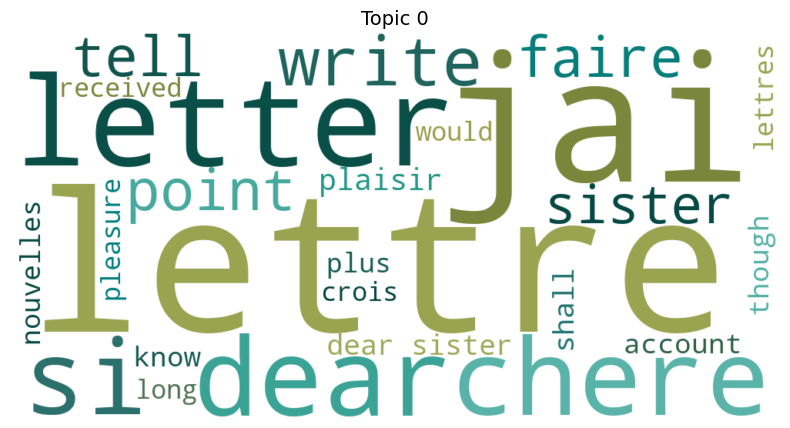

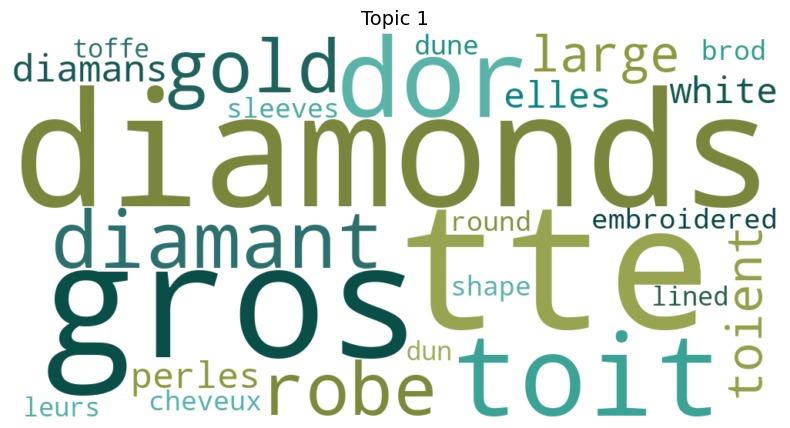

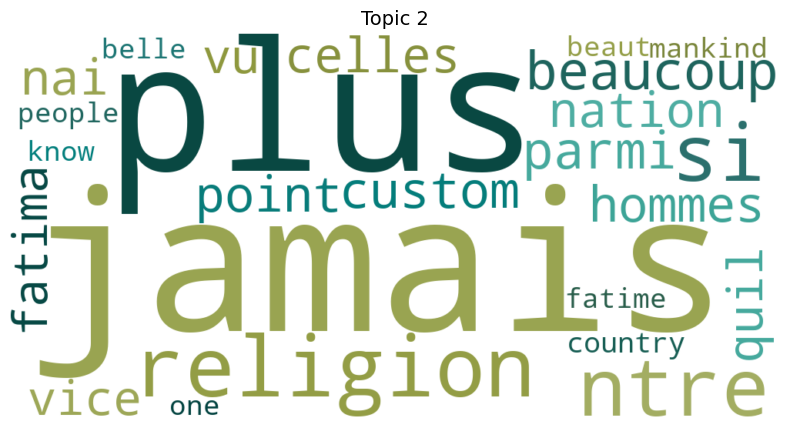

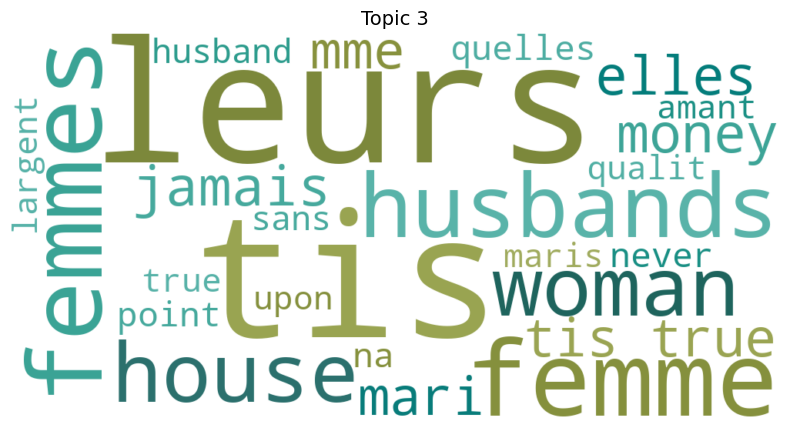

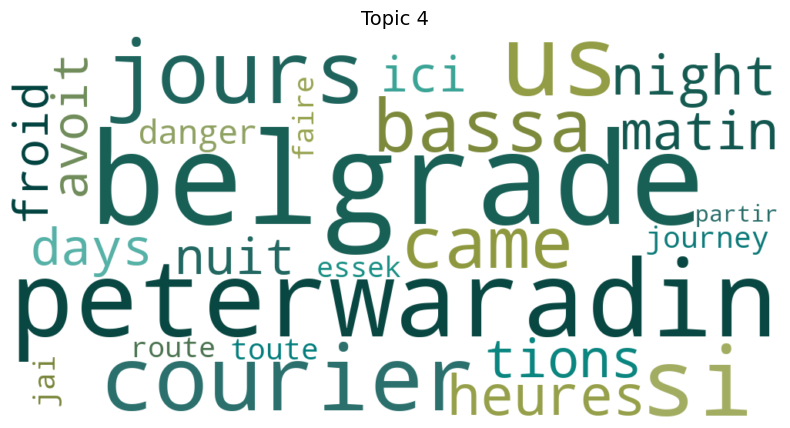

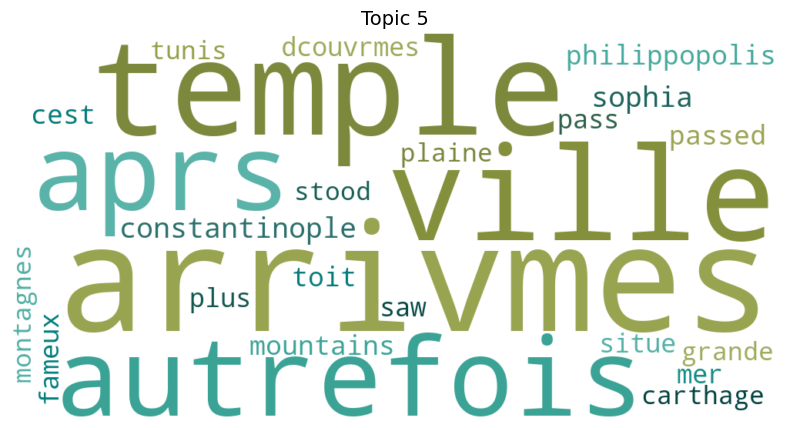

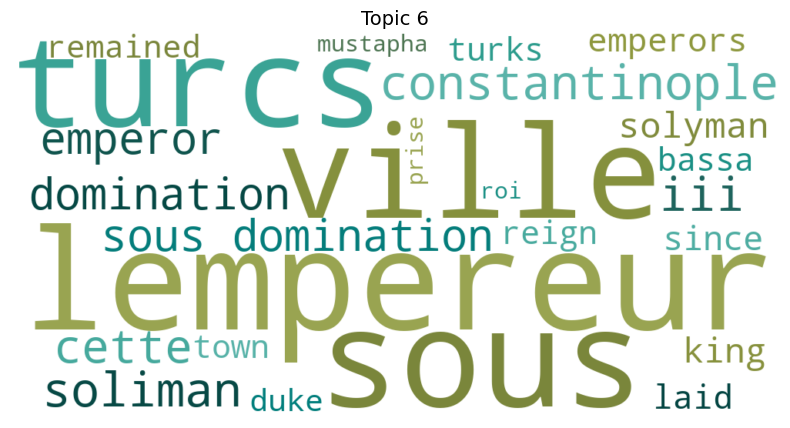

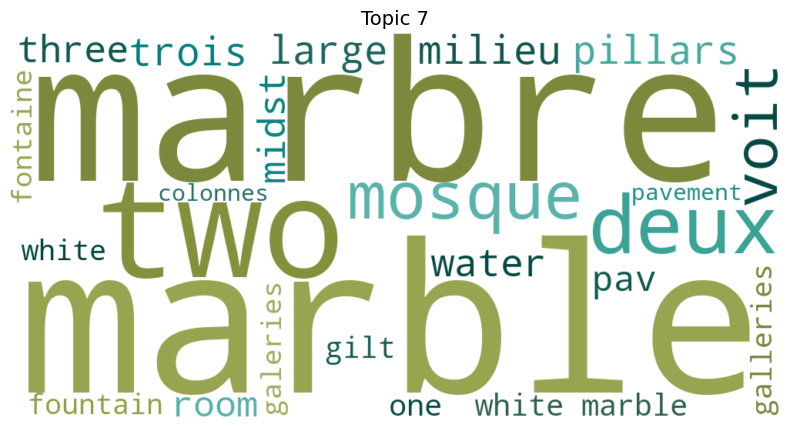

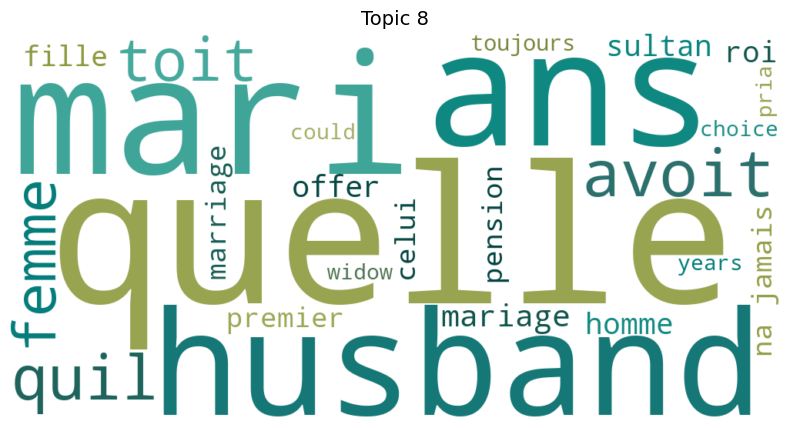

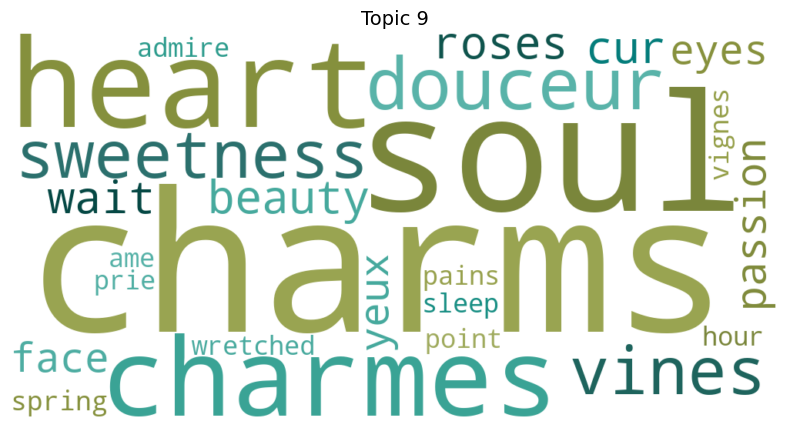

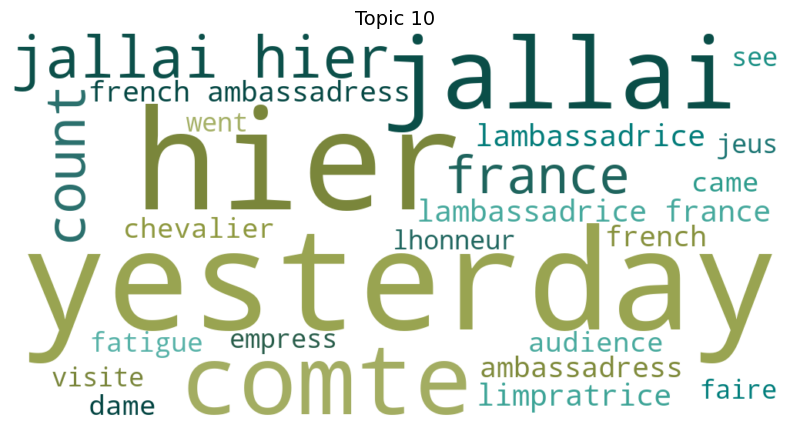

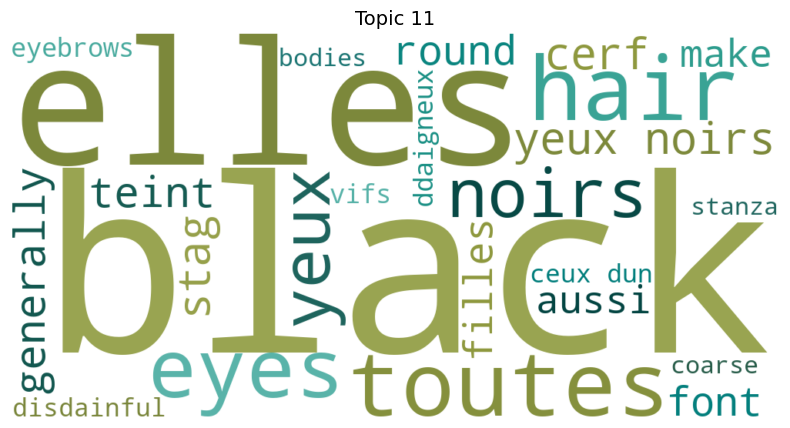

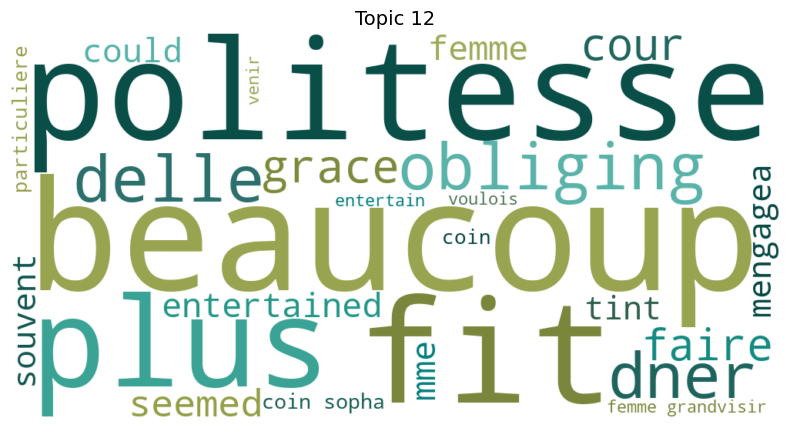

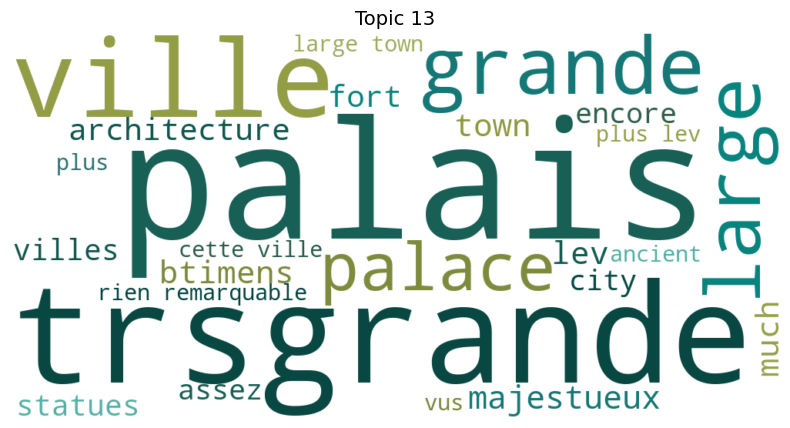

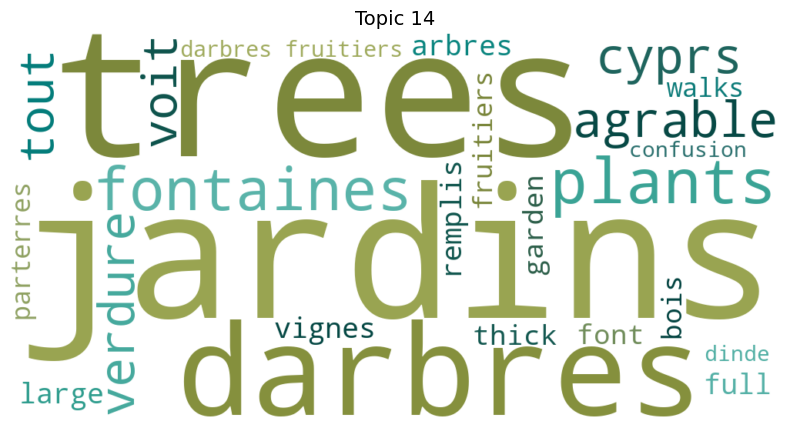

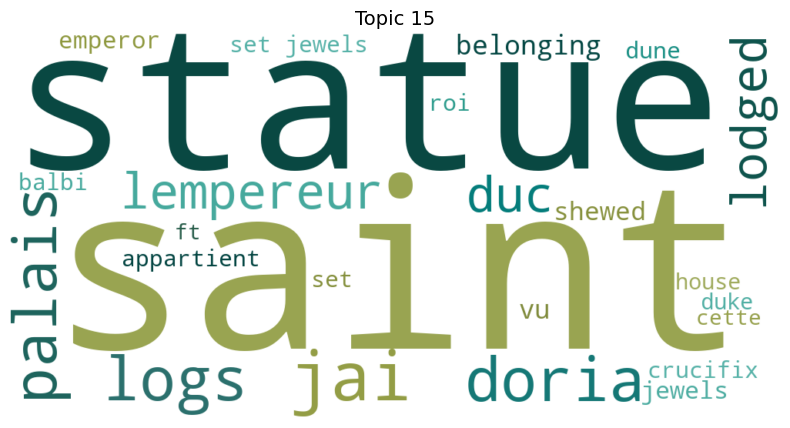

Saved word clouds to: /Users/mervetekgurler/Documents/montagu/units/03_unit/wordclouds


In [12]:
# ============================================================
# Step 4: Word clouds per topic
# ============================================================
import matplotlib.pyplot as plt
from wordcloud import WordCloud
from matplotlib.colors import LinearSegmentedColormap

# Custom color palette (kept from your original notebook)
colors = ["#7A863B", "#8F993E", "#A6B168", "#014240", "#175E54", "#2D716F", "#017E7C", "#279989", "#59B3A9"]
custom_color_map = LinearSegmentedColormap.from_list("custom_palette", colors)

wordcloud_directory = os.path.join(os.getcwd(), "wordclouds")
os.makedirs(wordcloud_directory, exist_ok=True)

width, height = 1000, 500

topics_dict = topic_model.get_topics()

for topic_id, topic_words in topics_dict.items():
    if topic_id == -1:  # skip the outlier/noise topic
        continue

    word_scores = dict(topic_words)
    if not word_scores:
        continue

    wordcloud = WordCloud(
        width=width,
        height=height,
        max_words=100,
        random_state=21,
        background_color="white",
        colormap=custom_color_map,
        # font_path="path/to/your/font.ttf",  # optional — omit to use matplotlib default font
    ).generate_from_frequencies(word_scores)

    plt.figure(figsize=(10, 5))
    plt.imshow(wordcloud, interpolation="bilinear")
    plt.axis("off")
    plt.title(f"Topic {topic_id}", fontsize=14)

    plt.savefig(
        os.path.join(wordcloud_directory, f"wordcloud_topic_{topic_id}.png"),
        bbox_inches="tight",
        dpi=150,
    )
    plt.show()
    plt.close()

print(f"Saved word clouds to: {wordcloud_directory}")

In [ ]:
# # ============================================================
# # OPTIONAL: word clouds split by language, per topic
# # (useful for your class: does each topic look different in EN vs FR?)
# # ============================================================
# df_filtered["topic"] = topics

# def wordcloud_for_subset(doc_subset, title, save_path):
#     if len(doc_subset) == 0:
#         print(f"No documents for: {title}")
#         return
#     text_blob = " ".join(doc_subset)
#     wc = WordCloud(
#         width=width, height=height, max_words=100,
#         background_color="white", colormap=custom_color_map, random_state=21,
#     ).generate(text_blob)
#     plt.figure(figsize=(10, 5))
#     plt.imshow(wc, interpolation="bilinear")
#     plt.axis("off")
#     plt.title(title, fontsize=14)
#     plt.savefig(save_path, bbox_inches="tight", dpi=150)
#     plt.show()
#     plt.close()

# for topic_id in sorted(df_filtered["topic"].unique()):
#     if topic_id == -1:
#         continue
#     for lang in ["en", "fr"]:
#         subset = df_filtered[(df_filtered["topic"] == topic_id) & (df_filtered["language"] == lang)]["sentence"].tolist()
#         save_path = os.path.join(wordcloud_directory, f"wordcloud_topic_{topic_id}_{lang}.png")
#         wordcloud_for_subset(subset, f"Topic {topic_id} ({lang})", save_path)

In [16]:
topic_model.get_topic(6, full=True)

{'Main': [('lempereur', np.float64(0.04420719156338784)),
  ('sous', np.float64(0.0424330705564923)),
  ('ville', np.float64(0.03747469948642927)),
  ('turcs', np.float64(0.03735179513868875)),
  ('constantinople', np.float64(0.03632491541927057)),
  ('soliman', np.float64(0.035984771626550234)),
  ('iii', np.float64(0.03519734119924915)),
  ('cette', np.float64(0.03398008653548026)),
  ('sous domination', np.float64(0.03332060547856987)),
  ('emperor', np.float64(0.0329750578005446)),
  ('domination', np.float64(0.03280816773230045)),
  ('solyman', np.float64(0.02998730968879186)),
  ('king', np.float64(0.02898335648304038)),
  ('since', np.float64(0.02799644618692833)),
  ('emperors', np.float64(0.027340139776917037)),
  ('laid', np.float64(0.027340139776917037)),
  ('turks', np.float64(0.025744462918862763)),
  ('reign', np.float64(0.025313288526240468)),
  ('town', np.float64(0.02517695338823268)),
  ('bassa', np.float64(0.024681862146060225)),
  ('remained', np.float64(0.023989847

In [17]:
# ============================================================
# Letter-level topic distribution 
# Reuses the already-fitted topic_model
# ============================================================

# Reconstruct full letter text by joining sentences back together, per letter, per language
letter_level_text_df = (
    df_filtered.groupby(["letter_id", "language"])["sentence"]
    .apply(lambda sents: " ".join(sents))
    .reset_index()
    .rename(columns={"sentence": "full_letter_text"})
)

letter_docs_for_distr = letter_level_text_df["full_letter_text"].tolist()

# Run approximate_distribution on full letters (not sentences)
letter_topic_distr, _ = topic_model.approximate_distribution(
    letter_docs_for_distr, window=8, stride=4
)

print("letter_topic_distr shape:", letter_topic_distr.shape)
# rows = letters (en + fr separately), columns = topics

# Build a labeled dataframe: one row per letter+language, one column per topic
letter_topic_distr_df = pd.DataFrame(
    letter_topic_distr,
    columns=[f"topic_{i}" for i in range(letter_topic_distr.shape[1])]
)
letter_topic_distr_df.insert(0, "language", letter_level_text_df["language"])
letter_topic_distr_df.insert(0, "letter_id", letter_level_text_df["letter_id"])

letter_topic_distr_df.head()

100%|██████████| 1/1 [00:00<00:00,  1.06it/s]

letter_topic_distr shape: (104, 16)


,letter_id,language,topic_0,topic_1,topic_2,topic_3,topic_4,topic_5,topic_6,topic_7,topic_8,topic_9,topic_10,topic_11,topic_12,topic_13,topic_14,topic_15
0,LTR-001,en,0.688473,0.0,0.079429,0.000000,0.000000,0.000000,0.0,0.000000,0.000000,0.000000,0.140848,0.000000,0.0,0.091251,0.000000,0.0
1,LTR-001,fr,0.278620,0.0,0.119151,0.028304,0.079102,0.000000,0.0,0.218385,0.024048,0.051018,0.052466,0.064497,0.0,0.058839,0.025569,0.0
2,LTR-002,en,0.302326,0.0,0.000000,0.000000,0.000000,0.000000,0.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.108744,0.588931,0.0
3,LTR-002,fr,0.391565,0.0,0.000000,0.000000,0.084345,0.090653,0.0,0.000000,0.000000,0.000000,0.000000,0.000000,0.0,0.089699,0.343738,0.0
4,LTR-003,en,0.150659,0.0,0.000000,0.102243,0.000000,0.000000,0.0,0.114040,0.000000,0.000000,0.158776,0.000000,0.0,0.055125,0.419157,0.0


In [20]:
letter_topic_distr_df.to_csv("montagu_letter_topic_distribution.csv", index=False)


In [21]:
# quick sanity check: which topic dominates each letter?
letter_topic_distr_df["dominant_topic"] = letter_topic_distr_df.filter(like="topic_").idxmax(axis=1)
letter_topic_distr_df[["letter_id", "language", "dominant_topic"]].head(10)

,letter_id,language,dominant_topic
0,LTR-001,en,topic_0
1,LTR-001,fr,topic_0
2,LTR-002,en,topic_14
3,LTR-002,fr,topic_0
4,LTR-003,en,topic_14
5,LTR-003,fr,topic_14
6,LTR-004,en,topic_13
7,LTR-004,fr,topic_15
8,LTR-005,en,topic_0
9,LTR-005,fr,topic_2


In [22]:
topic_model.visualize_distribution(letter_topic_distr[34], custom_labels=True)

In [23]:
topic_model.visualize_topics()

In [24]:
topic_model.visualize_barchart()

In [25]:
topic_model.visualize_hierarchy()

In [26]:
topic_model.visualize_heatmap()

In [28]:
# --- Step 1: Load letter-level dates and merge onto your sentence-level dataframe ---
df_meta = pd.read_csv("/Users/mervetekgurler/Documents/montagu/output/letters_metadata.csv")
df_meta["date_edited"] = pd.to_datetime(df_meta["date_edited"])

# merge onto df_filtered (your sentence-level dataframe, already aligned with docs/embeddings_filtered)
df_filtered = df_filtered.merge(
    df_meta[["letter_id", "date_edited"]],
    on="letter_id",
    how="left"
)

# sanity check: no missing dates after merge
print("Missing dates after merge:", df_filtered["date_edited"].isnull().sum())


Missing dates after merge: 0


In [29]:
# --- Step 2: Build the parallel timestamps list, matching docs order exactly ---
sentence_timestamps = df_filtered["date_edited"].tolist()

assert len(docs) == len(sentence_timestamps), (
    f"Mismatch: {len(docs)} docs vs {len(sentence_timestamps)} timestamps"
)

In [34]:
# --- Step 3: Run topics_over_time ---
topics_over_time_df = topic_model.topics_over_time(
    docs,
    sentence_timestamps,
    nr_bins=10  # adjust: number of time buckets across your date range
)

8it [00:00, 12.22it/s]


In [33]:
fig = topic_model.visualize_topics_over_time(topics_over_time_df, top_n_topics=10)
fig.write_html("montagu_topics_over_time.html")
fig.show()

In [ ]:
results = []

for index, row in df_topic_models.iterrows():
    # Initialize a dictionary to store results for this row
    row_result = {
        'Topic': row['Topic'],
        'Name': row['Name'],
        'Found_In': []  # Stores where the keyword was found
    }
    
    # Loop through each representation
    for representation in ['KeyBERT', 'MMR', 'POS']:
        representation_text = row[representation]
        
        # Check if any search keyword is present in the representation
        found_keywords = [keyword for keyword in search_words if keyword in representation_text]
        
        # If keywords are found, add the representation to the results
        if found_keywords:
            row_result['Found_In'].append({
                'Representation': representation,
                'Keywords': found_keywords
            })
    
    # If any keyword was found in any representation, add the results for this row to the main results list
    if row_result['Found_In']:
        results.append(row_result)


In [ ]:
for result in results:
    print(f"Topic {result['Topic']} ({result['Name']}):")
    for found in result['Found_In']:
        print(f"  Found in {found['Representation']}: {', '.join(found['Keywords'])}")
    print()


In [ ]:
topics_over_time['Year'] = pd.to_datetime(topics_over_time['Timestamp']).dt.year

In [ ]:
total_docs_per_year = topics_over_time.groupby('Year')['Frequency'].sum().reset_index()
total_docs_per_year.rename(columns={'Frequency': 'Total_Docs'}, inplace=True)

In [ ]:
normalized_topics = pd.merge(topics_over_time, total_docs_per_year, on='Year')

In [ ]:
normalized_topics['Normalized_Frequency'] = normalized_topics['Frequency'] / normalized_topics['Total_Docs']

In [ ]:
import matplotlib.pyplot as plt

# List of topics you want to visualize
topics_to_visualize = [0, 30, 31, 36]  # Add or remove topic numbers as needed

plt.figure(figsize=(12, 8))

# Loop through each topic and plot its normalized frequency over time
for topic in topics_to_visualize:
    topic_data = normalized_topics[normalized_topics['Topic'] == topic]
    plt.plot(topic_data['Year'], topic_data['Normalized_Frequency'], marker='o', linestyle='-', label=f'Topic {topic}')

plt.title('Normalized Frequency of Topics Over Years')
plt.xlabel('Year')
plt.ylabel('Normalized Frequency')
plt.legend()
plt.xticks(rotation=45)  # Rotate x-axis labels for better readability
plt.grid(True)
plt.tight_layout()  # Adjust layout to make room for the rotated x-axis labels
plt.show()


Word Clouds
repurposing the code from my AHA poster

In [ ]:
import matplotlib.pyplot as plt
from wordcloud import WordCloud
import numpy as np

In [ ]:
def create_oval_mask(width, height, center=None, axes=None):
    if center is None: # use the middle of the image
        center = (int(width / 2), int(height / 2))
    if axes is None: # size of axes
        axes = (int(width / 2), int(height / 2))

    y, x = np.ogrid[:height, :width]
    mask = (((x - center[0]) / axes[0]) ** 2 + ((y - center[1]) / axes[1]) ** 2) > 1
    return 255 * mask.astype(int)

# Create an oval mask
width, height = 1000, 500
mask = create_oval_mask(width, height)

In [ ]:
import matplotlib.pyplot as plt
from wordcloud import WordCloud, get_single_color_func
import os
from matplotlib.colors import LinearSegmentedColormap

# Custom Color Maps based on your provided color palette
colors = ["#7A863B", "#8F993E", "#A6B168", "#014240", "#175E54", "#2D716F", "#017E7C", "#279989", "#59B3A9"]
custom_color_map = LinearSegmentedColormap.from_list("custom_palette", colors)

# Specify the directory to save wordcloud images
wordcloud_directory = os.getcwd() + "/wordclouds"
os.makedirs(wordcloud_directory, exist_ok=True)

# Retrieve topics and their sizes
topics = topic_model.get_topics()

# Generate a word cloud for each topic
for topic_id, topic_words in topics.items():
    if topic_id == -1:  # Skip the outlier topic if present
        continue

    word_scores = dict(topic_words)

    wordcloud = WordCloud(
        width=width, height=height,
        max_words=200,  # Increase number of words
        mask=mask,  # Apply the mask
        random_state=21,
        background_color='white',
        colormap=custom_color_map,
        font_path='Roboto/Roboto-Light.ttf'  # Ensure this path is correct
    ).generate_from_frequencies(word_scores)

    plt.figure(figsize=(10, 5))
    plt.imshow(wordcloud, interpolation='bilinear')
    plt.axis('off')

    # Save each word cloud image to the specified directory
    plt.savefig(os.path.join(wordcloud_directory, f'wordcloud_topic_{topic_id}.png'))

In [35]:
# Pick the topic you want to inspect
topic_id = 6

# Extract that topic's probability/proportion across all letters
topic_probs = letter_topic_distr[:, topic_id]

# Get indices of the top N letters for this topic
top_n = 10
top_doc_indices = np.argsort(topic_probs)[-top_n:][::-1]

# Map those indices back to actual letter_id / language / text using
# letter_level_text_df, which was built in the same row order as letter_topic_distr
top_letters_for_topic = letter_level_text_df.iloc[top_doc_indices].copy()
top_letters_for_topic["topic_probability"] = topic_probs[top_doc_indices]

top_letters_for_topic[["letter_id", "language", "topic_probability", "full_letter_text"]]

,letter_id,language,topic_probability,full_letter_text
44,LTR-023,en,0.348508,"AT length, dear sister I am safely arrived, wi..."
26,LTR-014,en,0.311413,I HOPE my dear sister wants no new proofs of m...
45,LTR-023,fr,0.266675,"ENFIN, ma chere Soeur, je suis arrivée à Peter..."
87,LTR-044,fr,0.234594,J'Ai quitté Constantinople le 6. du mois derni...
11,LTR-006,fr,0.205451,JE n'ai reçu votre Lettre que la veille de mon...
86,LTR-044,en,0.193647,I LEFT Constantinople the sixth of the last mo...
30,LTR-016,en,0.193202,"I AM just come to Brunswick, a very old town, ..."
47,LTR-024,fr,0.186879,J'AVOIS résolu de vous écrire fort au long de ...
12,LTR-007,en,0.179510,"I AM now, my dear sister, safely arrived at Vi..."
49,LTR-025,fr,0.158475,J'AI fait un voyage qu'aucun Chrétien n'avoit ...


In [36]:
top_n = 5  # fewer per topic, since you'll be doing this for all 16 topics

n_topics = letter_topic_distr.shape[1]
top_letters_per_topic = {}

for topic_id in range(n_topics):
    topic_probs = letter_topic_distr[:, topic_id]
    top_doc_indices = np.argsort(topic_probs)[-top_n:][::-1]
    
    subset = letter_level_text_df.iloc[top_doc_indices].copy()
    subset["topic_probability"] = topic_probs[top_doc_indices]
    subset["topic_id"] = topic_id
    
    top_letters_per_topic[topic_id] = subset[["topic_id", "letter_id", "language", "topic_probability", "full_letter_text"]]

# combine into one dataframe for easy viewing/export
top_letters_all_topics = pd.concat(top_letters_per_topic.values(), ignore_index=True)
top_letters_all_topics.to_csv("montagu_top_letters_per_topic.csv", index=False)

top_letters_all_topics.head(20)

,topic_id,letter_id,language,topic_probability,full_letter_text
0,0,LTR-052,en,1.000000,"I Have this minute received a letter of yours,..."
1,0,LTR-022,fr,0.832048,JE suis si occupée à faire les préparatifs de ...
2,0,LTR-016,en,0.806798,"I AM just come to Brunswick, a very old town, ..."
3,0,LTR-022,en,0.732356,"I HAVE not time to answer your letter, being i..."
4,0,LTR-001,en,0.688473,"I FLATTER, myself, dear sister, that I shall g..."
5,1,LTR-039,en,0.436470,"I HAVE not written to you, dear sister, these ..."
6,1,LTR-029,en,0.407404,"I WISH to God, dear sister, that you were as r..."
7,1,LTR-039,fr,0.279003,"J'AI gardé avec vous, ma chere Soeur, un silen..."
8,1,LTR-029,fr,0.244994,"J'Ai lieu de me plaindre de vous, ma chere Sœu..."
9,1,LTR-009,en,0.206635,"THOUGH I have so lately troubled you, my dear ..."
